Found 1493 images belonging to 25 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,376,729 (12.88 MB)

 Trainable params: 3,376,729 (12.88 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.0509 - loss: 3.2206
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.1139 - loss: 2.9856
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.1996 - loss: 2.7052
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.2726 - loss: 2.4359
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.3751 - loss: 2.0922
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.4635 - loss: 1.8331
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.5050 - loss: 1.6537
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5841 - loss: 1.4508
Epoch 9/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6109 - loss: 1.3353
Epoch 10/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6410 - loss: 1.1828


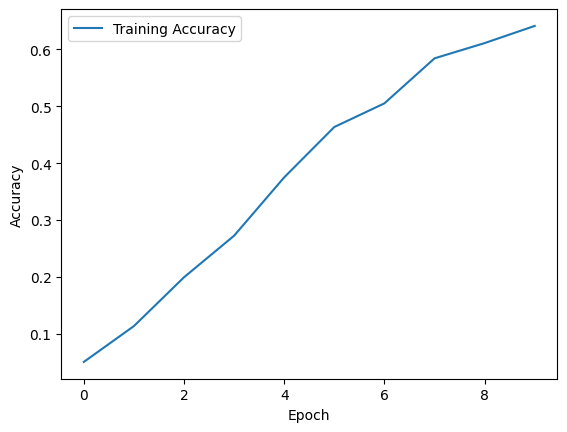

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

train_dir = "/content/drive/MyDrive/FACE_RAP001_K51"

img_width, img_height = 100, 100
batch_size = 128

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

# CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu',
           input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(train_generator.num_classes,
          activation='softmax')
])


model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train
epochs = 10

history = model.fit(
    train_generator,
    epochs=epochs
)

# Accuracy
plt.plot(history.history["accuracy"],
         label="Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


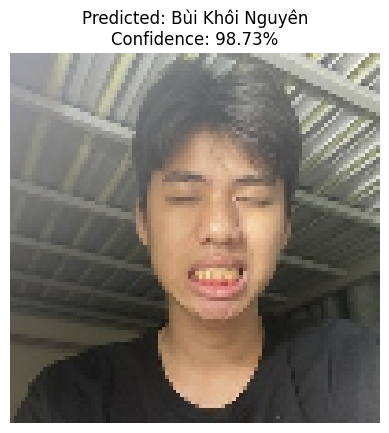

Người được nhận diện: Bùi Khôi Nguyên
Độ tin cậy: 98.73%


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/FACE_RAP001_K51/Bùi Khôi Nguyên/IMG_3223.JPG"

img = image.load_img(img_path, target_size=(100,100))
img_array = image.img_to_array(img) / 255.0
img_input = np.expand_dims(img_array, axis=0)

pred = model.predict(img_input)

class_names = list(train_generator.class_indices.keys())

predicted_class = np.argmax(pred)
predicted_name = class_names[predicted_class]
confidence = np.max(pred) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predicted_name}\nConfidence: {confidence:.2f}%")
plt.show()

print("Người được nhận diện:", predicted_name)
print(f"Độ tin cậy: {confidence:.2f}%")